# Результаты- Favorita

все визуализации по HW3
все графики — в `results/`

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-darkgrid")
RESULTS= Path("..")/"results"
%matplotlib inline

## 1. Сравнение моделей

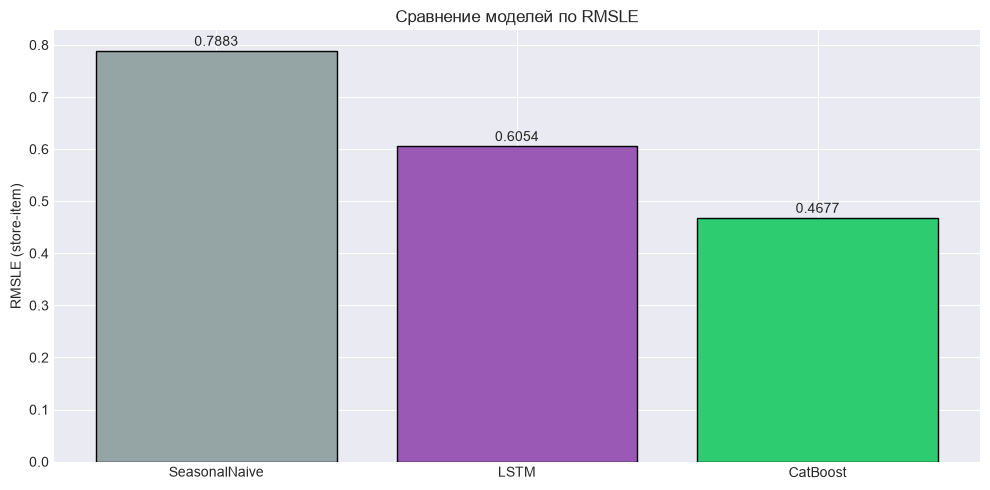

,Модель,RMSLE,Тип
0,SeasonalNaive,0.7883,бейзлайн
1,LSTM,0.6054,DL
2,CatBoost,0.4677,ML


In [6]:
res= pd.DataFrame({
    "Модель": ["SeasonalNaive","LSTM","CatBoost"],
    "RMSLE": [0.7883,0.6054,0.4677],
    "Тип": ["бейзлайн","DL","ML"],
                   })

fig,ax= plt.subplots(figsize=(10,5))
clrs= ["#95a5a6","#9b59b6","#2ecc71"]
bars= ax.bar(res["Модель"],res["RMSLE"],color=clrs,edgecolor="black")
ax.set_ylabel("RMSLE (store-item)")
ax.set_title("Сравнение моделей по RMSLE")
for bar,v in zip(bars,res["RMSLE"]):
    ax.text(bar.get_x() +bar.get_width()/2,v +0.01,
            f"{v:.4f}",ha="center")
plt.tight_layout()
plt.show()

res

## 2. Feature Importance CatBoost

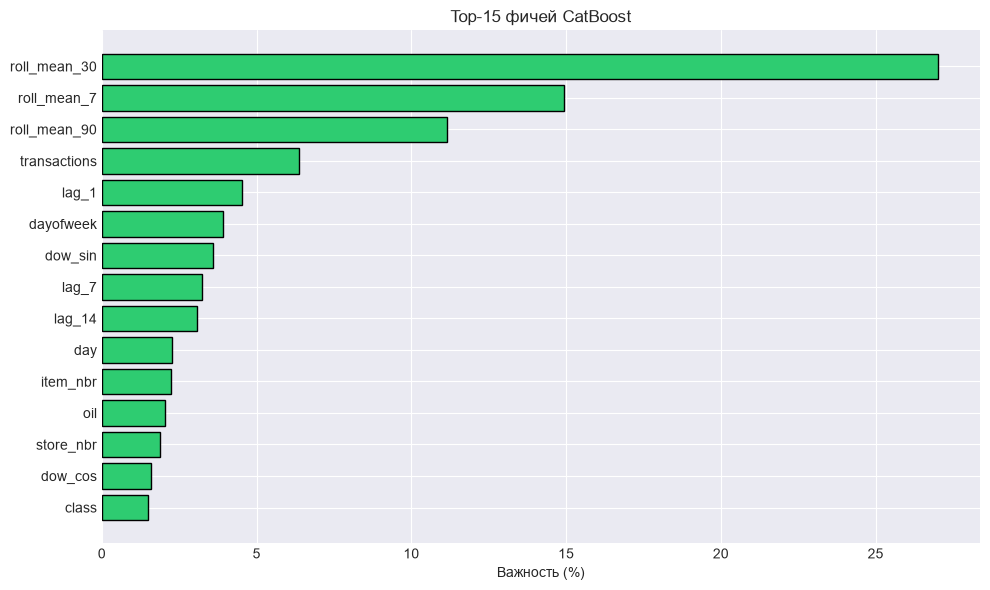

In [7]:
imp= pd.read_csv(RESULTS/"catboost_importance_full.csv")
top= imp.head(15)

fig,ax= plt.subplots(figsize=(10,6))
ax.barh(top["feature"],top["importance"],color="#2ecc71",edgecolor="black")
ax.set_xlabel("Важность (%)")
ax.set_title("Top-15 фичей CatBoost")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. LSTM -по эпохам

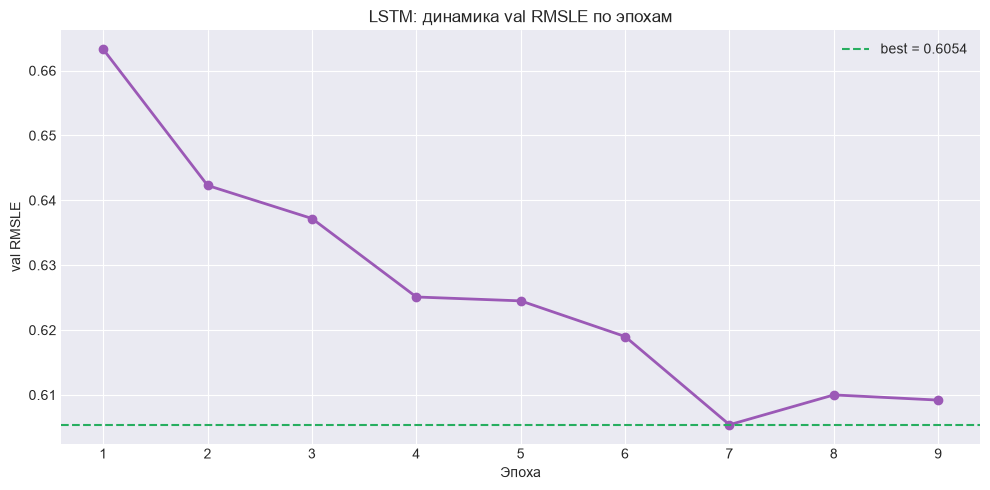

In [8]:
eps= [1,2,3,4,5,6,7,8,9]
vl= [0.6633,0.6423,0.6372,0.6251,0.6245,0.6190,0.6054,0.6100,0.6092]

fig,ax= plt.subplots(figsize=(10,5))
ax.plot(eps,vl,marker="o",linewidth=2,color="#9b59b6")
ax.axhline(y=min(vl),color="#27ae60",linestyle="--",
           label=f"best = {min(vl)}")
ax.set_xlabel("Эпоха")
ax.set_ylabel("val RMSLE")
ax.set_title("LSTM: динамика val RMSLE по эпохам")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## итоги анализа

- **CatBoost (ML)** победил по RMSLE = 0.4677.
- **LSTM (DL)** уступил CatBoostу с RMSLE 0.6054
- **SeasonalNaive** проиграл с RMSLE 0.7883.
- разница ML варианта над бейзлайном= **−41%**.
- Kaggle public получился **1.03390**, но это с учётом того, что наша моделька училась на небольшой подвыборке.